In [3]:
# Lê sinal
record = wfdb.rdrecord('path/100')

record.p_signal          # sinal em array NumPy (shape: amostras × canais)
record.sig_name          # nomes dos canais ['MLII', 'V5']
record.fs                # frequência de amostragem (360)
record.sig_len           # número total de amostras
record.units             # unidades do sinal ['mV', 'mV']
record.n_sig             # número de canais (2)

# Lê anotações
ann = wfdb.rdann('path/100', 'atr')

ann.sample               # posições dos batimentos [77, 370, 663, ...]
ann.symbol               # tipo de cada batimento ['N', 'N', 'A', ...]
ann.aux_note             # notas auxiliares (ritmo)

NameError: name 'wfdb' is not defined

In [1]:
import pandas as pd
import wfdb
import numpy as np
import matplotlib.pyplot as plt

data_path = r"C:\Users\fpmar\OneDrive\Ambiente de Trabalho\Programação\ML\mit-bih-ecg-analysis\mit-bih-arrhythmia-database-1.0.0\mit-bih-arrhythmia-database-1.0.0"

record = wfdb.rdrecord(f"{data_path}/100")

ann = wfdb.rdann(f'{data_path}/100', 'atr')

print("Chanels:", record.sig_name)
print("Freq:", record.fs, "Hz")
print("Duration:", record.sig_len / record.fs / 60, "min")
print("First Anotations:", ann.symbol[:20])

Chanels: ['MLII', 'V5']
Freq: 360 Hz
Duration: 30.092592592592595 min
First Anotations: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [2]:
df_ann = pd.DataFrame({
    "sample": ann.sample,
    "symbol": ann.symbol,
    "time_sec": ann.sample / record.fs 
})
print(df_ann.head(10))
print(df_ann['symbol'].value_counts())

   sample symbol  time_sec
0      18      +  0.050000
1      77      N  0.213889
2     370      N  1.027778
3     662      N  1.838889
4     946      N  2.627778
5    1231      N  3.419444
6    1515      N  4.208333
7    1809      N  5.025000
8    2044      A  5.677778
9    2402      N  6.672222
symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64


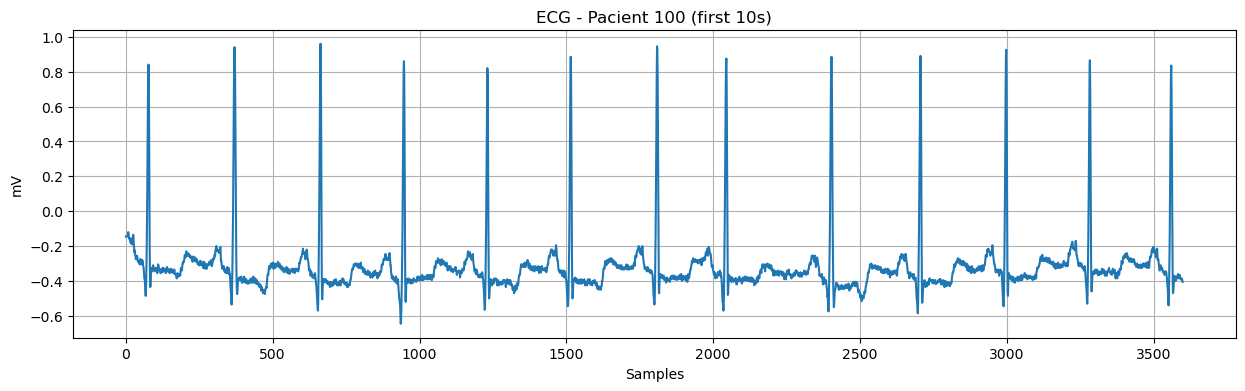

In [5]:
signal = record.p_signal[: ,0] # 0 -> MLII chanel
samples_10s = 10 * record.fs

plt.figure(figsize=(15, 4))
plt.plot(signal[:samples_10s])
plt.title('ECG - Pacient 100 (first 10s)')
plt.xlabel("Samples")
plt.ylabel("mV")
plt.grid(True)
plt.show()

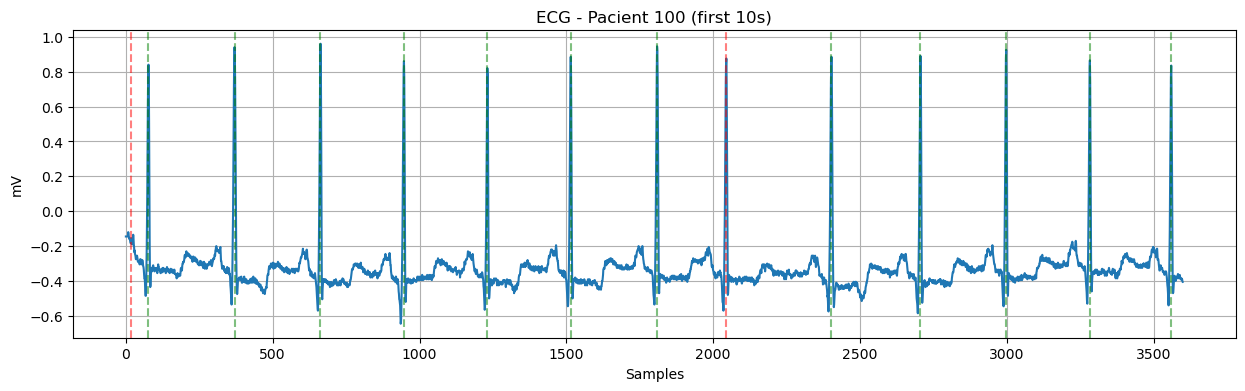

In [7]:
plt.figure(figsize=(15, 4))
plt.plot(signal[:samples_10s], label="ECG")

filt = df_ann["sample"]
ann_10s = df_ann[filt < samples_10s]

for _, row in ann_10s.iterrows(): # _ -> index
    color = "red" if row["symbol"] != "N" else "green"
    plt.axvline(x=row['sample'], color=color, alpha=0.5, linestyle='--') #alpha=transparency

plt.title('ECG - Pacient 100 (first 10s)')
plt.xlabel("Samples")
plt.ylabel("mV")
plt.grid(True)
plt.show()

In [9]:
import os

result = []
for f in os.listdir(data_path): #list of alll the files in the path
    if f.endswith('.hea'):
        result.append(f.replace('.hea', ''))
records = sorted(result)

df_all = pd.DataFrame()
for record in records:
    ann = wfdb.rdann(f'{data_path}/{record}', 'atr')
    df_temp = pd.DataFrame({
        "record": record,
        "sample": ann.sample,
        "symbol": ann.symbol
    })
    df_all = pd.concat([df_all, df_temp])

print(df_all.shape)
print(df_all.head(10))
print(df_all['symbol'].value_counts())

(112647, 3)
  record  sample symbol
0    100      18      +
1    100      77      N
2    100     370      N
3    100     662      N
4    100     946      N
5    100    1231      N
6    100    1515      N
7    100    1809      N
8    100    2044      A
9    100    2402      N
symbol
N    75052
L     8075
R     7259
V     7130
/     7028
A     2546
+     1291
f      982
F      803
~      616
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
Name: count, dtype: int64


In [10]:
df_all['rr_interval'] = df_all.groupby('record')["sample"].diff() / 360 * 1000
print(df_all.head(10))
print(df_all['rr_interval'].describe())

  record  sample symbol  rr_interval
0    100      18      +          NaN
1    100      77      N   163.888889
2    100     370      N   813.888889
3    100     662      N   811.111111
4    100     946      N   788.888889
5    100    1231      N   791.666667
6    100    1515      N   788.888889
7    100    1809      N   816.666667
8    100    2044      A   652.777778
9    100    2402      N   994.444444
count    112599.000000
mean        769.446492
std         227.268520
min          16.666667
25%         641.666667
50%         752.777778
75%         883.333333
max        5872.222222
Name: rr_interval, dtype: float64


In [13]:
filt = (df_all["rr_interval"] >= 100) & (df_all["rr_interval"] <= 5000)
df_all = df_all.loc[filt]

print(df_all.head(10))
print(df_all['rr_interval'].describe())

   record  sample symbol  rr_interval
1     100      77      N   163.888889
2     100     370      N   813.888889
3     100     662      N   811.111111
4     100     946      N   788.888889
5     100    1231      N   791.666667
6     100    1515      N   788.888889
7     100    1809      N   816.666667
8     100    2044      A   652.777778
9     100    2402      N   994.444444
10    100    2706      N   844.444444
count    112551.000000
mean        769.592772
std         225.440176
min         100.000000
25%         641.666667
50%         752.777778
75%         883.333333
max        4450.000000
Name: rr_interval, dtype: float64


In [15]:
df_all["symbol_grouped"] = df_all.groupby('record')["sample"].diff() / 360 * 1000

In [17]:
stats = df_all.groupby("symbol")["rr_interval"].agg(["min", "max", "mean"])
bpm = 60000 / stats
bpm.columns = ["min_bpm", "max_bpm", "mean_bpm"]
print(bpm)

           min_bpm     max_bpm    mean_bpm
symbol                                    
!       415.384615  105.365854  202.748334
"       308.571429   37.305699   87.474515
+       583.783784   46.153846  142.543857
/       583.783784   59.668508   72.320670
A       583.783784   62.427746   97.510359
E        72.972973   23.920266   57.672544
F       583.783784   33.128834  103.546099
J       220.408163   54.545455   89.047832
L       553.846154   35.702479   73.833006
N       600.000000   29.958391   75.960263
Q       480.000000   45.473684   87.394108
R       540.000000   13.483146   64.989245
S       102.857143   98.630137  100.699301
V       583.783784   47.058824  118.339560
[       209.708738  151.048951  177.291382
]       276.923077   81.203008  142.105263
a       400.000000   92.307692  126.374912
e       152.112676   51.306413   80.148423
f       392.727273   60.335196   73.236013
j       432.000000   17.955112   58.332741
x       553.846154  119.337017  309.556694
|       568

In [47]:
beats_per_patient = df_all.groupby(["record", "symbol"])["symbol"].size()
print(beats_per_patient.head(20))

record  symbol
100     A           33
        N         2239
        V            1
101     A            3
        N         1860
        Q            1
        |            4
        ~            4
102     +            4
        /         2028
        N           99
        V            4
        f           56
103     A            2
        N         2082
        ~            6
104     +           43
        /         1379
        N          163
        Q           18
Name: symbol, dtype: int64


In [95]:
std_per_patient = df_all.groupby("record")["rr_interval"].std()
print(std_per_patient)

record
100     50.595472
101     83.084583
102     43.091450
103     59.115727
104    114.352532
105    121.770580
106    276.449309
107     44.642288
108    178.564797
109     41.678990
111     54.806337
112     41.701925
113    100.104752
114    142.467326
115     96.856842
116     84.673794
117     63.740912
118    102.757657
119    281.267111
121    106.044432
122     44.943497
123    124.120131
124    120.181555
200    184.442684
201    355.771909
202    286.263574
203    211.874705
205     75.463337
207    300.036320
208    149.228544
209     98.975159
210    130.114227
212     54.229783
213     53.332616
214    188.769304
215     64.734103
217    130.475681
219    243.048857
220    116.765995
221    208.990469
222    230.811956
223    116.865022
228    219.238623
230    170.266254
231    131.803690
232    599.980779
233    138.857216
234     42.045993
Name: rr_interval, dtype: float64


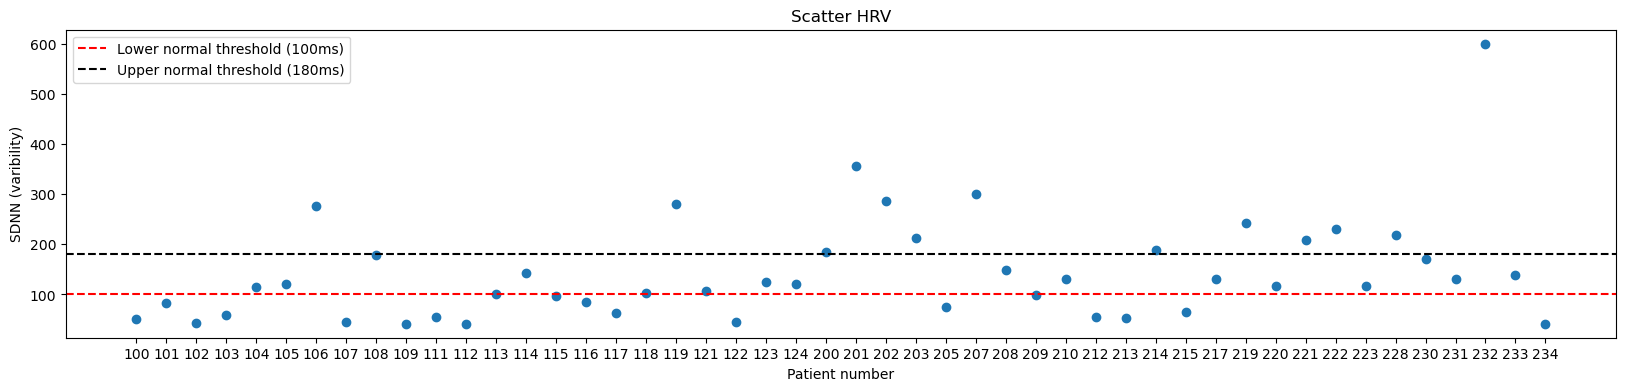

In [79]:
plt.figure(figsize=(20, 4))
plt.scatter(std_per_patient.index, std_per_patient.values)
plt.xlabel("Patient number")
plt.ylabel("SDNN (varibility)")
plt.title("Scatter HRV")
plt.axhline(y=100, color='red', linestyle='--', label='Lower normal threshold (100ms)')
plt.axhline(y=180, color='black', linestyle='--', label='Upper normal threshold (180ms)')
plt.legend()
plt.show()

In [115]:
main_symbols = ['A', 'V', 'L', 'R', '/', '+']
filt = df_all["symbol"].isin(main_symbols)
df_filtered = df_all[filt]
print(df_filtered.shape)
print(df_filtered['symbol'].value_counts())

(33267, 6)
symbol
L    8073
R    7257
V    7127
/    7026
A    2546
+    1238
Name: count, dtype: int64


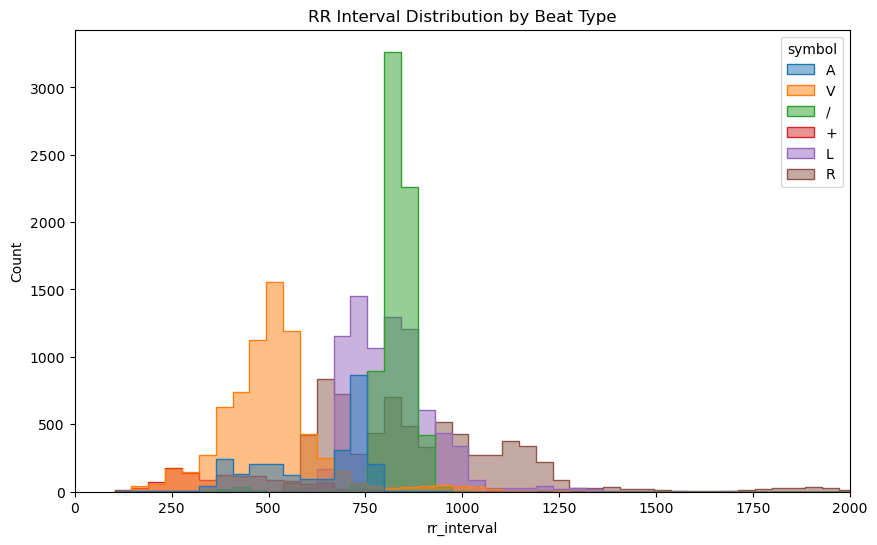

In [117]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='rr_interval', hue='symbol', bins=100, alpha=0.5, element='step')
plt.title('RR Interval Distribution by Beat Type')
plt.xlim(0, 2000)
plt.show()

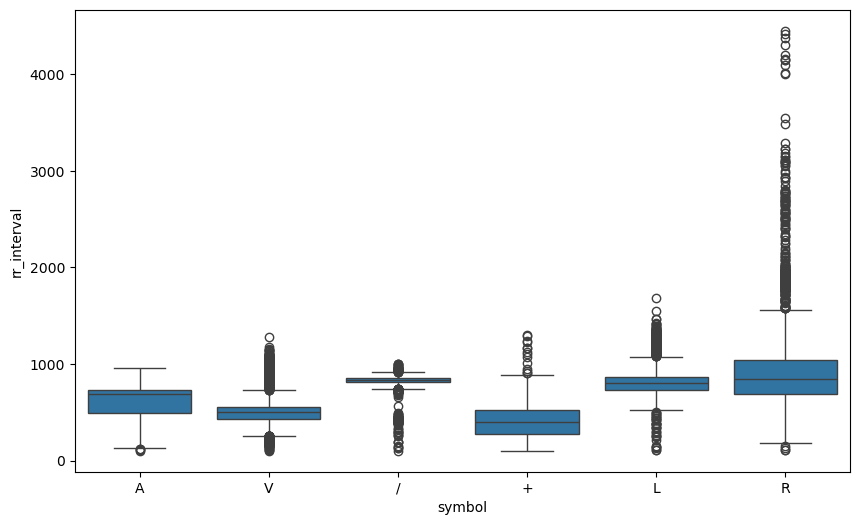

In [127]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered, x='symbol', y='rr_interval')
plt.show()